# Certified Counterfactual Generation on 2D Spiral Data

This notebook demonstrates the **CertifiedAtlas** API on the 2D spiral toy dataset, where we can **directly visualize** the certified polytopes and assess preimage approximation quality.

Unlike the MNIST latent-space case (notebook 3.1), in 2D we can:
- Plot the actual polytope shapes as filled polygons
- Visually verify coverage of the decision regions
- See exactly where counterfactuals land relative to polytope boundaries
- Ground-truth the quantitative metrics against visual inspection

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch.utils.data import TensorDataset

import sys
sys.path.insert(0, '../src')
from models.classifiers import SimpleClassifier
from preimage_sampling import CertifiedAtlas

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

cmap = plt.colormaps.get_cmap('tab10')

## 2 – Load Data & Model

We load the 2D spiral test set (5 classes, 400 samples) and the pre-trained `SimpleClassifier` (2→64→32→5).

In [ ]:
dataset = torch.load('../data/TOY Spiral/train_spiral.pt', weights_only=True)
X_all = torch.stack([x for x, _ in dataset])
y_all = torch.tensor([y for _, y in dataset])
n_classes = len(set(y_all.numpy()))

print(f'Dataset: {len(dataset)} samples, {n_classes} classes')
print(f'Input dim: {X_all.shape[1]}')

# Load pre-trained classifier from Lightning checkpoint
from training.lit_classifier import LitClassifier
lit = LitClassifier.load_from_checkpoint(
    '../checkpoints/spiral_classifier/Spiral-Classifier-162-0.0327.ckpt',
    model=SimpleClassifier(num_classes=n_classes)
)
model = lit.model.to(device).eval()

# Verify accuracy
with torch.no_grad():
    preds = model(X_all.to(device)).argmax(dim=1).cpu()
    acc = (preds == y_all).float().mean()
print(f'Classifier accuracy: {acc*100:.1f}%')

# Quick scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
for c in range(n_classes):
    mask = y_all == c
    ax.scatter(X_all[mask, 0], X_all[mask, 1], s=10, alpha=0.6,
               c=[cmap(c)], label=f'Class {c}')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('2D Spiral Dataset (test set)')
plt.tight_layout()
plt.show()

## 3 – Build Certified Atlas

Each polytope is:

$$P_i = \bigl\{\, \mathbf{x} \in \mathbb{R}^2 \;\big|\; A_i \mathbf{x} + \mathbf{b}_i \geq \mathbf{0}\bigr\} \;\cap\; \mathcal{B}_p(\mathbf{x}_i, \varepsilon)$$

In 2D, we can use `build_unions=True` to compute Shapely polygon unions for visualization.

In [3]:
atlas = CertifiedAtlas(model, dataset, device)

atlas.build(
    eps=0.1,
    norm=2,
    build_unions=True,
    verbose=True
)

Building certified atlas (eps=0.1, L2 norm)...
  Computing LiRPA bounds...


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 17.99it/s]


  Building BVH spatial indices...
    Class 0: 320 polytopes, tree depth 10
    Class 1: 320 polytopes, tree depth 10
    Class 2: 320 polytopes, tree depth 10
    Class 3: 320 polytopes, tree depth 10
    Class 4: 320 polytopes, tree depth 10
  Building polygon unions...
Done! Total: 1600 polytopes across 5 classes


CertifiedAtlas(n_classes=5, built)

## 3.1 – Preimage Approximation Quality

We assess the quality of the preimage approximation through four metrics:

| Metric | What it measures | Collapse signal |
|--------|-----------------|------------------|
| **Feasibility** | Can the center satisfy all constraints? | Infeasible = no polytope |
| **Center margins** | Distance from center to each halfspace boundary | All margins $\approx 0$ = paper-thin |
| **Chebyshev radius** | Largest inscribed $L_2$-ball | $r \approx 0$ vs $r = \varepsilon$ (unconstrained) |
| **Volume ratio** | $\mathrm{vol}(\text{polytope}) / \mathrm{vol}(\text{box})$ via Monte Carlo | Ratio $\approx 0$ = collapsed |

In 2D we can also compute **exact polygon area** via Shapely as a ground-truth volume measure.

In [4]:
from preimage_sampling.geometry.polytopes import make_polygon

# ── Compute all polytope-level metrics ──────────────────────────────────────────
d = 2
N_MC = 5000
box_area = (2 * atlas.eps) ** 2  # area of the bounding box in 2D

polytope_records = []
for label in range(n_classes):
    bd = atlas.bounds[label]
    n = len(bd['X'])
    for i in range(n):
        center = bd['X'][i]
        lA_i = bd['lA'][i]
        lbias_i = bd['lbias'][i]

        # Center margins
        margins = lA_i @ center + lbias_i
        min_margin = margins.min()
        mean_margin = margins.mean()
        feasible = min_margin >= -1e-6

        # Chebyshev radius
        cheb_r = 0.0
        if feasible:
            row_norms = np.linalg.norm(lA_i, axis=1, ord=2)
            row_norms = np.maximum(row_norms, 1e-12)
            cheb_r = np.min(margins / row_norms)
            cheb_r = min(cheb_r, atlas.eps)

        # Volume ratio via Monte Carlo
        vol_ratio = 0.0
        if feasible:
            samples = center + atlas.eps * (2 * np.random.rand(N_MC, d) - 1)
            halfspace_ok = np.all(samples @ lA_i.T + lbias_i >= 0, axis=1)
            vol_ratio = halfspace_ok.mean()

        # Exact polygon area (2D-specific)
        poly_area = 0.0
        try:
            polygon = make_polygon(lA_i, lbias_i, center, atlas.eps)
            if polygon is not None:
                poly_area = polygon.area
        except Exception:
            pass

        polytope_records.append({
            'class': label,
            'idx': i,
            'feasible': feasible,
            'min_margin': min_margin,
            'mean_margin': mean_margin,
            'chebyshev_r': cheb_r,
            'cheb_r_ratio': cheb_r / atlas.eps if atlas.eps > 0 else 0,
            'volume_ratio': vol_ratio,
            'polygon_area': poly_area,
            'area_ratio': poly_area / box_area if box_area > 0 else 0,
        })

poly_df = pd.DataFrame(polytope_records)
feasible_df = poly_df[poly_df['feasible']]
has_area_df = feasible_df[feasible_df['polygon_area'] > 1e-12]

# ── Summary table ─────────────────────────────────────────────────────────
print(f'Atlas: eps={atlas.eps}, L{atlas.norm} norm, {d}D input space')
print(f'Total polytopes: {len(poly_df)}, feasible: {len(feasible_df)} '
      f'({100*len(feasible_df)/len(poly_df):.1f}%), '
      f'with area: {len(has_area_df)} ({100*len(has_area_df)/len(poly_df):.1f}%)\n')

summary_rows = []
for label in range(n_classes):
    cls = feasible_df[feasible_df['class'] == label]
    cls_area = has_area_df[has_area_df['class'] == label]
    total_cls = poly_df[poly_df['class'] == label]
    summary_rows.append({
        'Class': label,
        'Feasible': f'{len(cls)}/{len(total_cls)}',
        'Min margin (med)': f'{cls["min_margin"].median():.4f}' if len(cls) > 0 else '-',
        'Cheb. r/eps (med)': f'{cls["cheb_r_ratio"].median():.2%}' if len(cls) > 0 else '-',
        'Vol. ratio (med)': f'{cls["volume_ratio"].median():.2%}' if len(cls) > 0 else '-',
        'Area (med)': f'{cls_area["polygon_area"].median():.6f}' if len(cls_area) > 0 else '-',
        'Area/box (med)': f'{cls_area["area_ratio"].median():.2%}' if len(cls_area) > 0 else '-',
    })
print(pd.DataFrame(summary_rows).to_string(index=False))
print(f'\nOverall: Cheb. r/eps={feasible_df["cheb_r_ratio"].median():.2%}, '
      f'Vol. ratio={feasible_df["volume_ratio"].median():.2%}, '
      f'Area/box={has_area_df["area_ratio"].median():.2%}')

Atlas: eps=0.1, L2 norm, 2D input space
Total polytopes: 1600, feasible: 1141 (71.3%), with area: 1141 (71.3%)

 Class Feasible Min margin (med) Cheb. r/eps (med) Vol. ratio (med) Area (med) Area/box (med)
     0  206/320           3.9678            25.80%           51.67%   0.020706         51.77%
     1  212/320           4.8156            35.04%           68.97%   0.027472         68.68%
     2  257/320           6.0165            87.94%           93.02%   0.037336         93.34%
     3  168/320           6.3668            35.40%           69.63%   0.027933         69.83%
     4  298/320          11.2598            53.54%           78.44%   0.031372         78.43%

Overall: Cheb. r/eps=44.41%, Vol. ratio=73.40%, Area/box=73.49%


INFO     18:25:01     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:01     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:01     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:01     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:01     [category.py:224] Using categorical units to plot a list o

/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


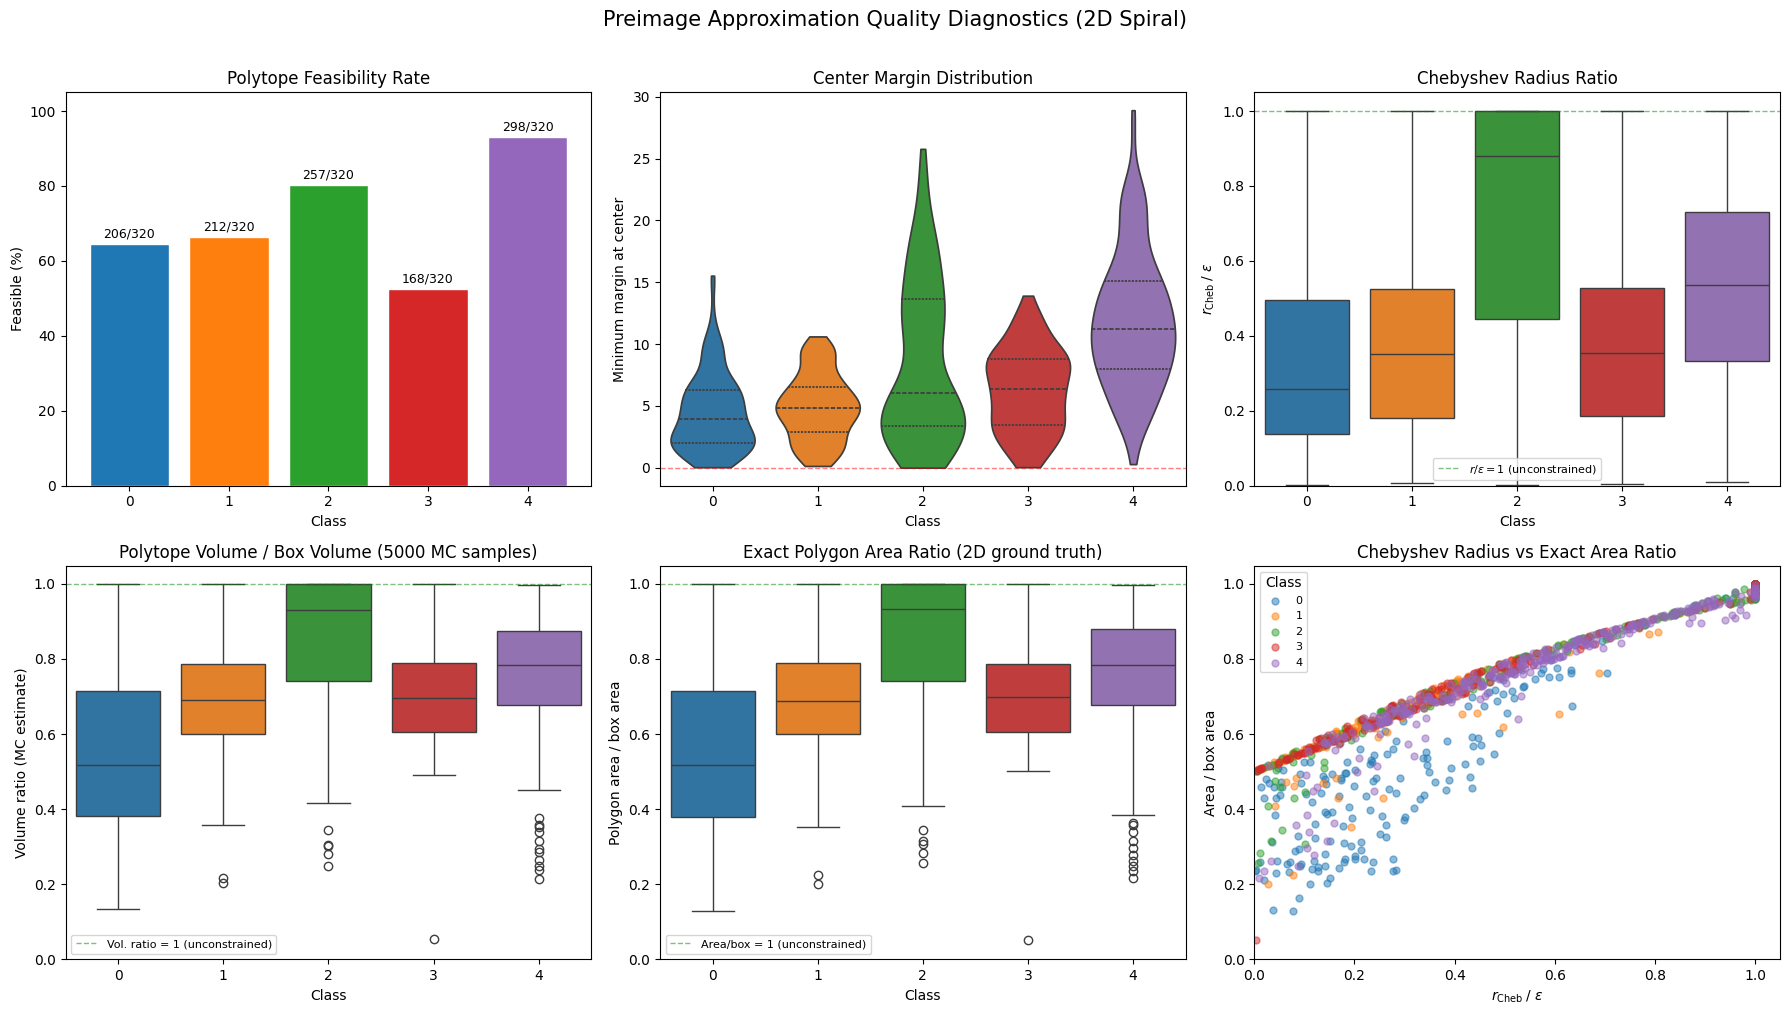

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── (0,0) Feasibility bar chart ────────────────────────────────────────────
ax = axes[0, 0]
feas_counts = poly_df.groupby('class')['feasible'].agg(['sum', 'count'])
bars = ax.bar(range(n_classes), feas_counts['sum'] / feas_counts['count'] * 100,
              color=[cmap(i) for i in range(n_classes)], edgecolor='white')
ax.set_xlabel('Class')
ax.set_ylabel('Feasible (%)')
ax.set_title('Polytope Feasibility Rate')
ax.set_ylim(0, 105)
ax.set_xticks(range(n_classes))
for bar, row in zip(bars, feas_counts.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{int(row.sum)}/{int(row.count)}', ha='center', va='bottom', fontsize=9)

# ── (0,1) Center margin distribution ───────────────────────────────────────
ax = axes[0, 1]
sns.violinplot(ax=ax, x='class', y='min_margin', data=feasible_df,
               hue='class', palette='tab10', legend=False, inner='quart', cut=0)
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Class')
ax.set_ylabel('Minimum margin at center')
ax.set_title('Center Margin Distribution')

# ── (0,2) Chebyshev radius / eps ratio ────────────────────────────────────
ax = axes[0, 2]
sns.boxplot(ax=ax, x='class', y='cheb_r_ratio', data=feasible_df,
            hue='class', palette='tab10', legend=False)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
           label=r'$r/\varepsilon = 1$ (unconstrained)')
ax.set_xlabel('Class')
ax.set_ylabel(r'$r_{\mathrm{Cheb}} \;/\; \varepsilon$')
ax.set_title('Chebyshev Radius Ratio')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── (1,0) Volume ratio ─────────────────────────────────────────────────
ax = axes[1, 0]
sns.boxplot(ax=ax, x='class', y='volume_ratio', data=feasible_df,
            hue='class', palette='tab10', legend=False)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
           label='Vol. ratio = 1 (unconstrained)')
ax.set_xlabel('Class')
ax.set_ylabel('Volume ratio (MC estimate)')
ax.set_title(f'Polytope Volume / Box Volume ({N_MC} MC samples)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── (1,1) Exact polygon area distribution ─────────────────────────────────
ax = axes[1, 1]
sns.boxplot(ax=ax, x='class', y='area_ratio', data=has_area_df,
            hue='class', palette='tab10', legend=False)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
           label='Area/box = 1 (unconstrained)')
ax.set_xlabel('Class')
ax.set_ylabel('Polygon area / box area')
ax.set_title('Exact Polygon Area Ratio (2D ground truth)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── (1,2) Chebyshev radius vs area ratio scatter ────────────────────────
ax = axes[1, 2]
for label in range(n_classes):
    cls = has_area_df[has_area_df['class'] == label]
    ax.scatter(cls['cheb_r_ratio'], cls['area_ratio'],
               c=[cmap(label)], alpha=0.5, s=25, label=str(label))
ax.set_xlabel(r'$r_{\mathrm{Cheb}} \;/\; \varepsilon$')
ax.set_ylabel('Area / box area')
ax.set_title('Chebyshev Radius vs Exact Area Ratio')
ax.legend(fontsize=8, title='Class')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.suptitle('Preimage Approximation Quality Diagnostics (2D Spiral)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_118807/999477912.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


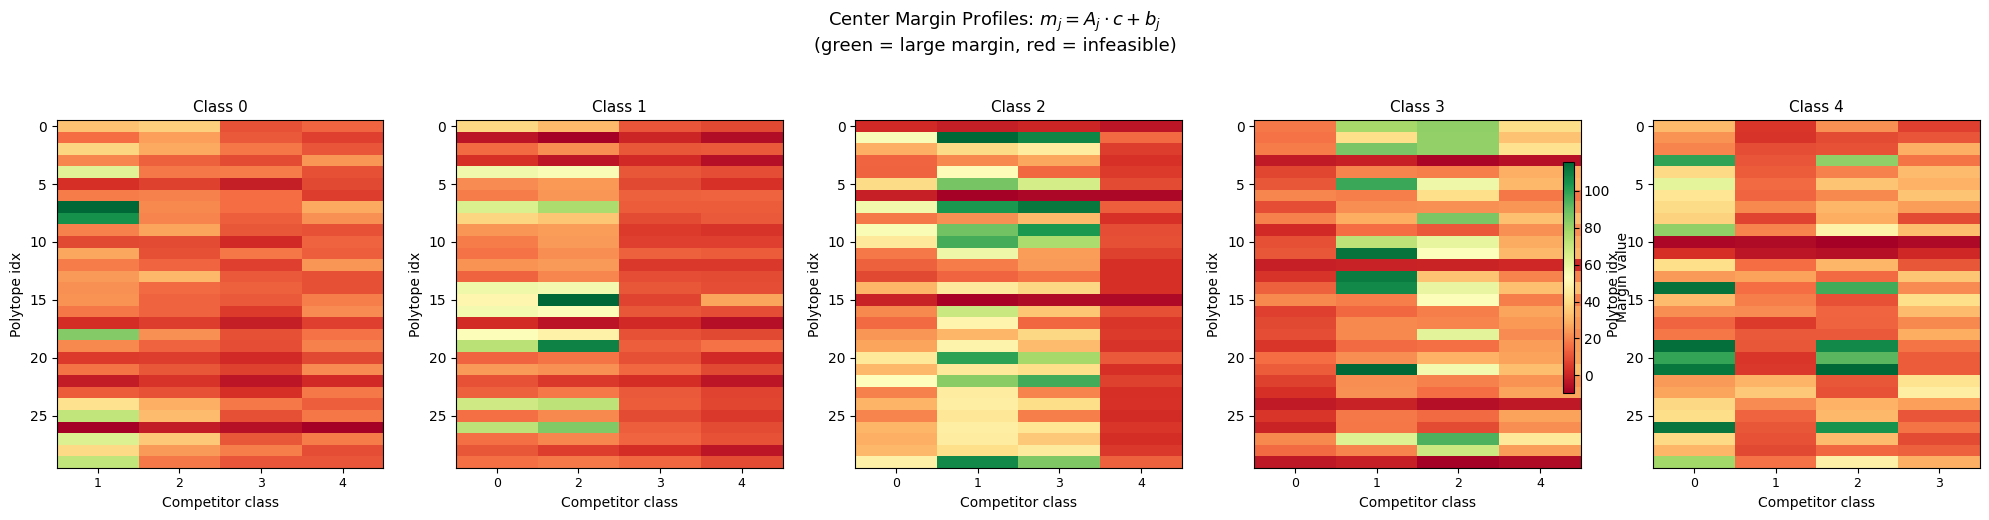

In [6]:
# ── Margin profile heatmap per class ───────────────────────────────────────
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 5))

for label in range(n_classes):
    ax = axes[label]
    bd = atlas.bounds[label]
    n_show = min(30, len(bd['X']))

    margin_matrix = np.zeros((n_show, bd['lA'].shape[1]))
    for i in range(n_show):
        margin_matrix[i] = bd['lA'][i] @ bd['X'][i] + bd['lbias'][i]

    competitor_labels = [str(c) for c in range(n_classes) if c != label]

    im = ax.imshow(margin_matrix, aspect='auto', cmap='RdYlGn',
                   vmin=margin_matrix.min(), vmax=max(margin_matrix.max(), 1e-6))
    ax.set_xlabel('Competitor class')
    ax.set_ylabel('Polytope idx')
    ax.set_title(f'Class {label}', fontsize=11)
    ax.set_xticks(range(len(competitor_labels)))
    ax.set_xticklabels(competitor_labels, fontsize=9)

plt.suptitle('Center Margin Profiles: $m_j = A_j \\cdot c + b_j$\n'
             '(green = large margin, red = infeasible)', fontsize=13, y=1.03)
fig.colorbar(im, ax=axes, shrink=0.6, label='Margin value')
plt.tight_layout()
plt.show()

## 4 – Visualize Certified Regions (2D)

The key advantage of 2D: we can directly plot each polytope as a filled polygon and see the preimage coverage.

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/numpy/_core/function_base.py:184: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = conv.wrap(y.astype(dtype, copy=False))
/home/gabrielepintus/.local/lib/python3.13/site-packages/matplotlib/transforms.py:2866: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  if (not np.isfinite(vmin)) or (not np.isfinite(vmax)):


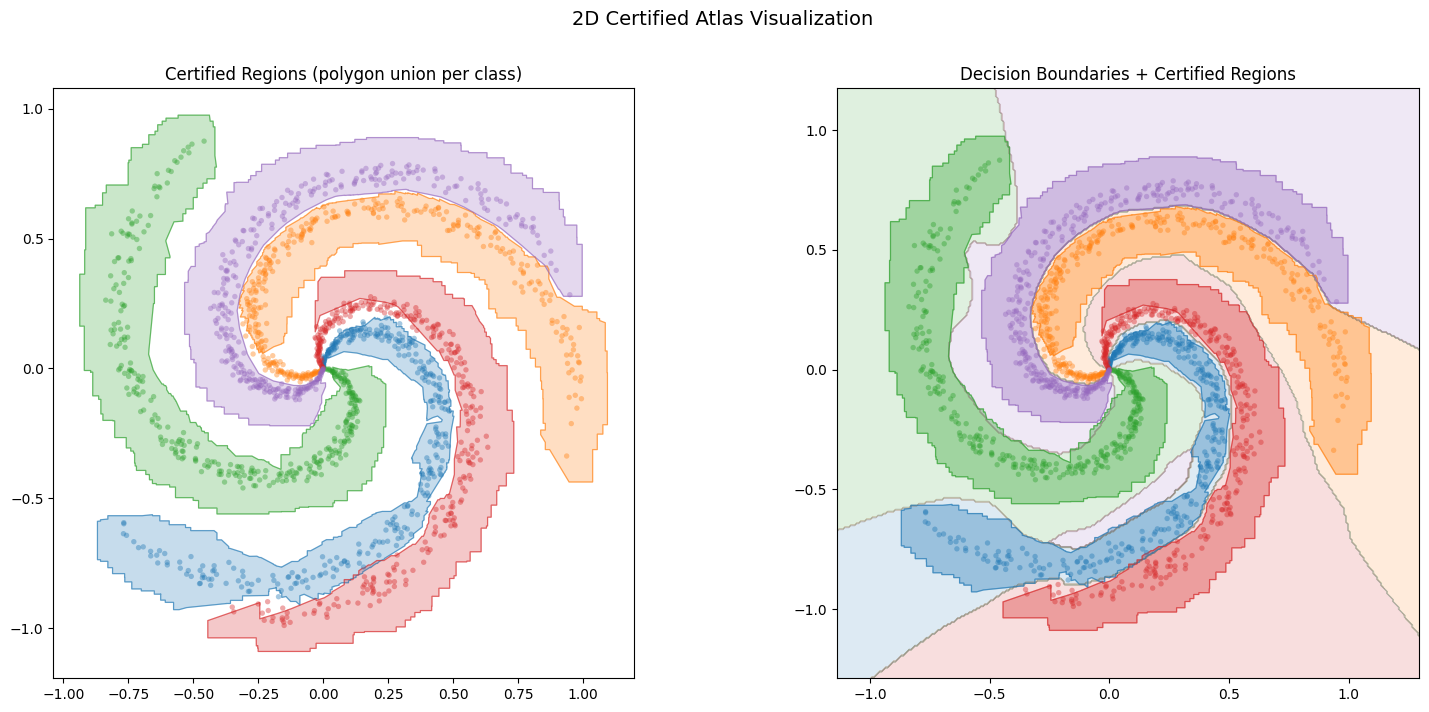

In [7]:
def plot_atlas(atlas, ax=None, alpha=0.3, show_data=True):
    """Plot certified regions as filled Shapely polygons."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    for label in range(atlas.n_classes):
        color = cmap(label)
        if show_data:
            X = atlas.bounds[label]['X']
            ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.4, c=[color],
                       zorder=3, edgecolors='none')
        union = atlas.get_class_union(label)
        if union is None or union.is_empty:
            continue
        geoms = [union] if union.geom_type == 'Polygon' else list(union.geoms)
        for g in geoms:
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, alpha=alpha, color=color)
            ax.plot(xs, ys, lw=0.8, color=color, alpha=0.6)
    ax.set_aspect('equal')
    return ax

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: certified regions with data
plot_atlas(atlas, ax=axes[0], alpha=0.25)
axes[0].set_title('Certified Regions (polygon union per class)', fontsize=12)

# Right: decision boundary heatmap + certified regions overlay
ax = axes[1]
x_min, x_max = X_all[:, 0].min() - 0.3, X_all[:, 0].max() + 0.3
y_min, y_max = X_all[:, 1].min() - 0.3, X_all[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = model(grid.to(device)).argmax(dim=1).cpu().numpy().reshape(xx.shape)
ax.contourf(xx, yy, zz, alpha=0.15, levels=np.arange(-0.5, n_classes),
            colors=[cmap(i) for i in range(n_classes)])
ax.contour(xx, yy, zz, levels=np.arange(0.5, n_classes - 0.5),
           colors='gray', linewidths=0.5, alpha=0.5)
plot_atlas(atlas, ax=ax, alpha=0.35, show_data=True)
ax.set_title('Decision Boundaries + Certified Regions', fontsize=12)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.suptitle('2D Certified Atlas Visualization', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5 – Generate Counterfactuals

In [8]:
source_class = 0
n_queries = 5
query_points = atlas.bounds[source_class]['X'][:n_queries]

print(f'Generating counterfactuals for {n_queries} queries from class {source_class}\n')

all_results = {}
for target_class in range(n_classes):
    if target_class == source_class:
        continue

    results = []
    for i, x0 in enumerate(query_points):
        result = atlas.find_counterfactual(x0, target_class, method='bvh')
        results.append(result)

    all_results[target_class] = results
    n_ok = sum(r.success for r in results)
    avg_dist = np.mean([r.distance for r in results if r.success]) if n_ok > 0 else float('inf')
    avg_qp = np.mean([r.n_qp_solved for r in results])
    print(f'  -> Class {target_class}: {n_ok}/{n_queries} success, '
          f'avg dist={avg_dist:.4f}, avg QPs={avg_qp:.1f}')

Generating counterfactuals for 5 queries from class 0

  -> Class 1: 5/5 success, avg dist=0.5431, avg QPs=63.6
  -> Class 2: 5/5 success, avg dist=0.2100, avg QPs=17.2
  -> Class 3: 5/5 success, avg dist=0.1009, avg QPs=49.8
  -> Class 4: 5/5 success, avg dist=0.4601, avg QPs=36.6


## 6 – Verify Counterfactuals

In [9]:
print('Verifying counterfactual validity:\n')

all_valid = True
for target_class, results in all_results.items():
    for i, result in enumerate(results):
        if not result.success:
            all_valid = False
            continue
        verification = atlas.verify_counterfactual(result.x_cf, target_class)
        if not verification['valid']:
            print(f'  INVALID: query {i} -> class {target_class}, '
                  f'pred={verification["predicted"]}')
            all_valid = False

print(f'All counterfactuals valid: {all_valid}')

Verifying counterfactual validity:

All counterfactuals valid: True


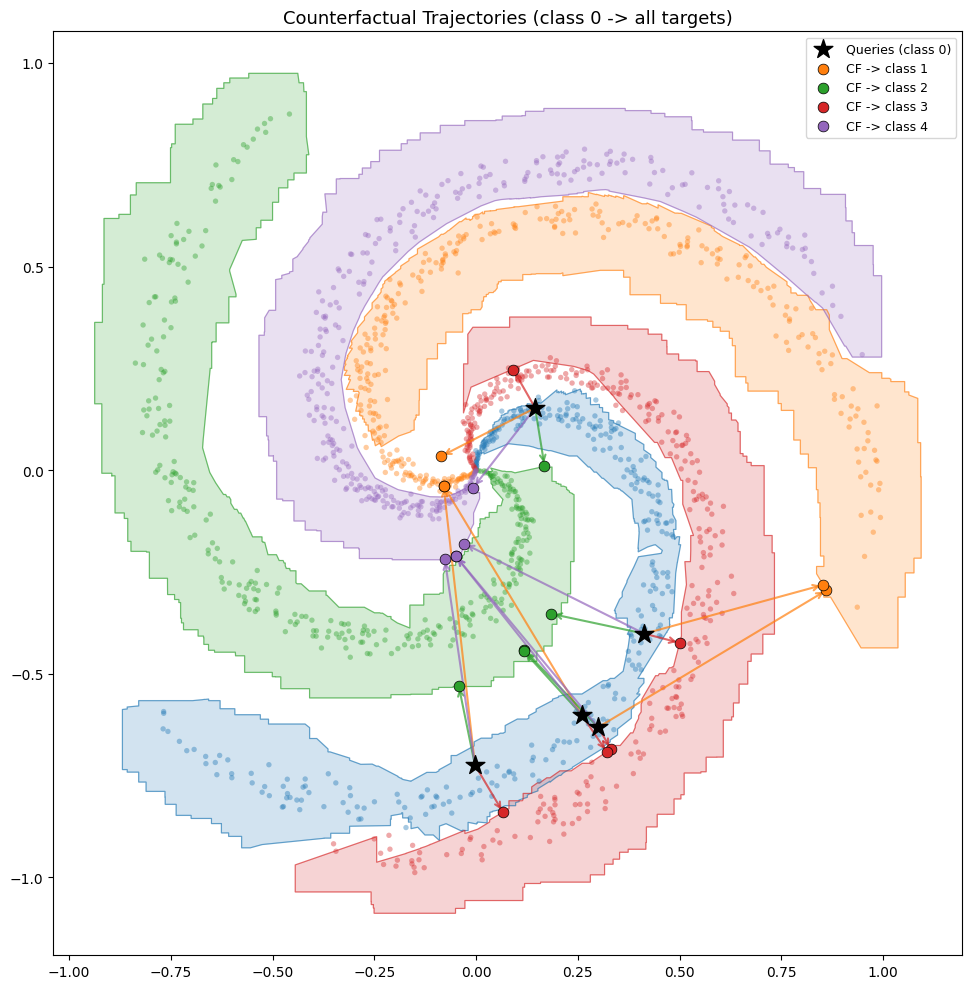

In [10]:
# ── Visualize counterfactual trajectories on 2D atlas ────────────────────

fig, ax = plt.subplots(figsize=(10, 10))
plot_atlas(atlas, ax=ax, alpha=0.2)

# Plot query points
ax.scatter(query_points[:, 0], query_points[:, 1], marker='*', s=200,
           c='black', zorder=5, label=f'Queries (class {source_class})')

# Plot arrows and CF destinations
for target_class, results in all_results.items():
    color = cmap(target_class)
    for i, result in enumerate(results):
        if not result.success:
            continue
        x0 = query_points[i]
        x_cf = result.x_cf
        ax.annotate('', xy=x_cf, xytext=x0,
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=1.5, alpha=0.7))
        ax.scatter(x_cf[0], x_cf[1], c=[color], s=60, zorder=5,
                   edgecolors='black', linewidth=0.5)

# Legend for target classes
for t in sorted(all_results.keys()):
    ax.scatter([], [], c=[cmap(t)], s=60, label=f'CF -> class {t}',
               edgecolors='black', linewidth=0.5)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Counterfactual Trajectories (class {source_class} -> all targets)', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# ── Counterfactuals sorted by distance ───────────────────────────────────

for qi in range(min(3, n_queries)):
    x_q = query_points[qi]
    cf_data = []
    for target_class, results in all_results.items():
        result = results[qi]
        if not result.success:
            continue
        cf_data.append({
            'target': target_class,
            'distance': result.distance,
            'x_cf': result.x_cf,
        })
    sorted_cf = sorted(cf_data, key=lambda d: d['distance'])
    ranking = ', '.join(f'class {d["target"]} (d={d["distance"]:.4f})' for d in sorted_cf)
    print(f'Query {qi} [{x_q[0]:.3f}, {x_q[1]:.3f}]: {ranking}')

Query 0 [0.300, -0.632]: class 3 (d=0.0618), class 2 (d=0.2623), class 4 (d=0.5477), class 1 (d=0.6538)
Query 1 [0.413, -0.402]: class 3 (d=0.0896), class 2 (d=0.2338), class 1 (d=0.4555), class 4 (d=0.4957)
Query 2 [0.259, -0.601]: class 3 (d=0.1102), class 2 (d=0.2117), class 4 (d=0.4978), class 1 (d=0.6564)


### 6.1 – Polytope Value-Add: Are Polytopes Better Than Nearest-Neighbor?

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **NN distance ratio** | $d(\mathbf{x}_q, \mathbf{x}_{cf}) / d(\mathbf{x}_q, \text{NN}_{target})$ | $< 1$: polytope adds value |
| **CF displacement** | $d(\mathbf{x}_{cf}, \mathbf{c}_{polytope}) / \varepsilon$ | $\approx 0$: collapsed to center |

In [12]:
value_add_rows = []
for target_class, results in all_results.items():
    target_centers = atlas.bounds[target_class]['X']

    for qi in range(n_queries):
        result = results[qi]
        if not result.success:
            continue

        x_q = query_points[qi]
        x_cf = result.x_cf

        # NN distance
        dists_to_centers = np.linalg.norm(target_centers - x_q, axis=1)
        nn_dist = dists_to_centers.min()

        # CF distance
        cf_dist = result.distance

        # CF displacement from closest polytope center
        dists_cf_to_centers = np.linalg.norm(target_centers - x_cf, axis=1)
        cf_displacement = dists_cf_to_centers.min()

        value_add_rows.append({
            'source': source_class,
            'target': target_class,
            'query_idx': qi,
            'cf_dist': cf_dist,
            'nn_dist': nn_dist,
            'nn_ratio': cf_dist / nn_dist if nn_dist > 0 else 1.0,
            'cf_displacement': cf_displacement,
            'cf_disp_ratio': cf_displacement / atlas.eps if atlas.eps > 0 else 0,
        })

va_df = pd.DataFrame(value_add_rows)

n_improved = (va_df['nn_ratio'] < 1.0 - 1e-6).sum()
n_equal = ((va_df['nn_ratio'] >= 1.0 - 1e-6) & (va_df['nn_ratio'] <= 1.0 + 1e-6)).sum()
n_total = len(va_df)

print(f'Polytope value-add analysis ({n_total} counterfactuals):\n')
print(f'  CF closer than NN:      {n_improved}/{n_total} ({100*n_improved/n_total:.1f}%)')
print(f'  CF = NN (collapsed):    {n_equal}/{n_total} ({100*n_equal/n_total:.1f}%)')
print(f'  NN ratio (median):      {va_df["nn_ratio"].median():.4f}')
print(f'  CF displacement/eps:    {va_df["cf_disp_ratio"].median():.4f} (median)')
print()

print(f'{"Target":>7} {"Improved":>10} {"NN ratio":>12} {"Disp/eps":>12}')
print('-' * 45)
for t in sorted(va_df['target'].unique()):
    sub = va_df[va_df['target'] == t]
    n_imp = (sub['nn_ratio'] < 1.0 - 1e-6).sum()
    print(f'{t:>7d} {n_imp:>5d}/{len(sub):<4d} {sub["nn_ratio"].median():>12.4f} '
          f'{sub["cf_disp_ratio"].median():>12.4f}')

Polytope value-add analysis (20 counterfactuals):

  CF closer than NN:      15/20 (75.0%)
  CF = NN (collapsed):    0/20 (0.0%)
  NN ratio (median):      0.8455
  CF displacement/eps:    0.8632 (median)

 Target   Improved     NN ratio     Disp/eps
---------------------------------------------
      1     2/5          1.0180       0.5558
      2     5/5          0.7004       1.0000
      3     4/5          0.7904       0.4479
      4     4/5          0.8535       1.0000


INFO     18:25:04     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:04     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:04     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:04     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


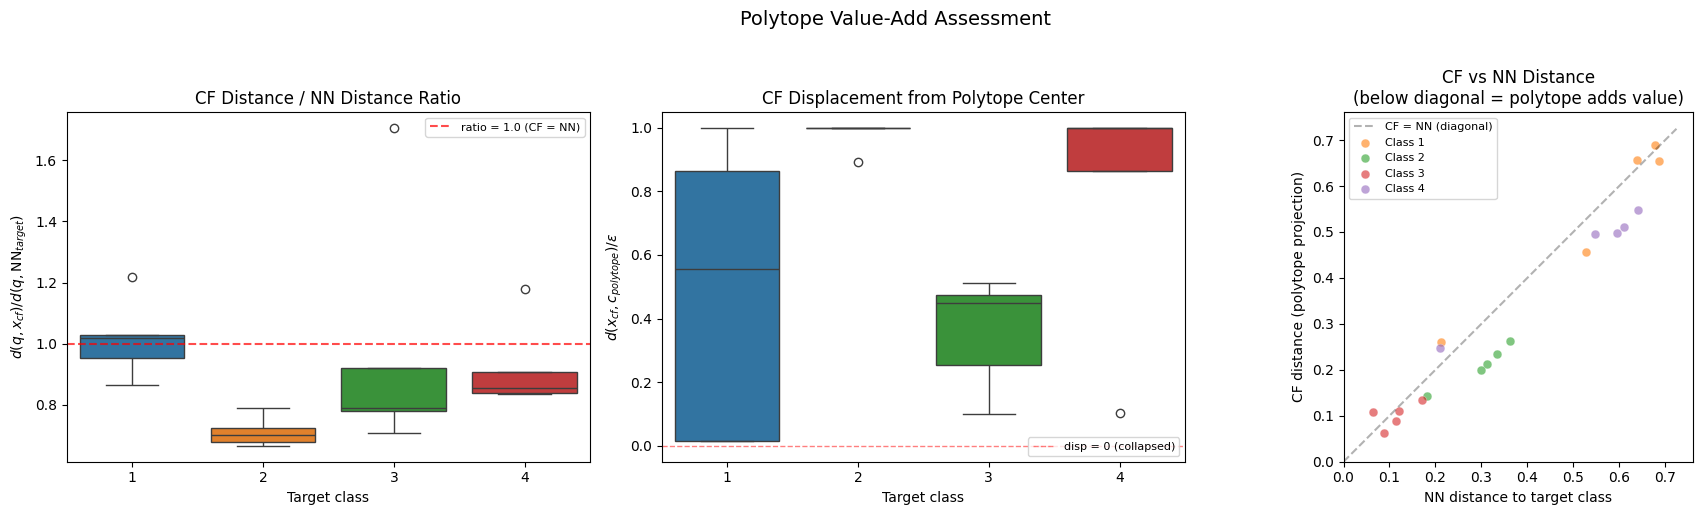

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (0) NN ratio by target class ─────────────────────────────────────────
ax = axes[0]
sns.boxplot(ax=ax, x='target', y='nn_ratio', data=va_df,
            hue='target', palette='tab10', legend=False)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='ratio = 1.0 (CF = NN)')
ax.set_xlabel('Target class')
ax.set_ylabel(r'$d(q, x_{cf}) / d(q, \mathrm{NN}_{target})$')
ax.set_title('CF Distance / NN Distance Ratio')
ax.legend(fontsize=8)

# ── (1) CF displacement / eps ──────────────────────────────────────────
ax = axes[1]
sns.boxplot(ax=ax, x='target', y='cf_disp_ratio', data=va_df,
            hue='target', palette='tab10', legend=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5,
           label='disp = 0 (collapsed)')
ax.set_xlabel('Target class')
ax.set_ylabel(r'$d(x_{cf}, c_{polytope}) / \varepsilon$')
ax.set_title('CF Displacement from Polytope Center')
ax.set_ylim(bottom=-0.05)
ax.legend(fontsize=8)

# ── (2) CF vs NN scatter ───────────────────────────────────────────────
ax = axes[2]
max_val = max(va_df['cf_dist'].max(), va_df['nn_dist'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='CF = NN (diagonal)')
for t in sorted(va_df['target'].unique()):
    sub = va_df[va_df['target'] == t]
    ax.scatter(sub['nn_dist'], sub['cf_dist'], c=[cmap(t)], alpha=0.6,
               s=40, label=f'Class {t}', edgecolors='white', linewidth=0.3)
ax.set_xlabel('NN distance to target class')
ax.set_ylabel('CF distance (polytope projection)')
ax.set_title('CF vs NN Distance\n(below diagonal = polytope adds value)')
ax.legend(fontsize=8)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_aspect('equal')

plt.suptitle('Polytope Value-Add Assessment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7 – δ-Robust Counterfactuals

In [14]:
x_query = atlas.bounds[0]['X'][0]
target = 1

print(f'Query: class 0, target: class {target}')
print(f'Atlas norm: L{atlas.norm}, eps={atlas.eps}\n')

delta_values = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.07, 0.1]

print(f'--- Robustness norm = L{atlas.norm} (same as atlas) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(x_query, target, method='bvh', delta=delta)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: dist={result.distance:.4f}, '
              f'QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED')

print()
print('--- Robustness norm = L\u221e (cross-norm) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(x_query, target, method='bvh',
                                       delta=delta, robust_norm=np.inf)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: dist={result.distance:.4f}, '
              f'QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED')

Query: class 0, target: class 1
Atlas norm: L2, eps=0.1

--- Robustness norm = L2 (same as atlas) ---
  delta=0.000: dist=0.6538, QPs=62, valid=True
  delta=0.001: dist=0.6548, QPs=62, valid=True
  delta=0.005: dist=0.6588, QPs=63, valid=True
  delta=0.010: dist=0.6638, QPs=64, valid=True
  delta=0.020: dist=0.6738, QPs=66, valid=True
  delta=0.050: dist=0.7043, QPs=81, valid=True
  delta=0.070: dist=0.7264, QPs=85, valid=True
  delta=0.100: FAILED

--- Robustness norm = L∞ (cross-norm) ---
  delta=0.000: dist=0.6538, QPs=62, valid=True
  delta=0.001: dist=0.6552, QPs=62, valid=True
  delta=0.005: dist=0.6607, QPs=63, valid=True
  delta=0.010: dist=0.6676, QPs=66, valid=True
  delta=0.020: dist=0.6813, QPs=74, valid=True
  delta=0.050: dist=0.7249, QPs=85, valid=True
  delta=0.070: dist=0.7762, QPs=101, valid=True
  delta=0.100: FAILED


## 8 – Benchmark: BVH vs k-NN Search

In [15]:
import time

n_test = 10
test_queries = atlas.bounds[0]['X'][:n_test]
target = 2
n_polytopes = len(atlas.bounds[target]['X'])

print(f'Benchmarking {n_test} queries (class 0 -> class {target})')
print(f'Total polytopes in target class: {n_polytopes}')
print('=' * 60)

bvh_qps, knn_qps = [], []
bvh_times, knn_times = [], []

for i, x0 in enumerate(test_queries):
    t0 = time.time()
    result_bvh = atlas.find_counterfactual(x0, target, method='bvh')
    t_bvh = time.time() - t0

    t0 = time.time()
    result_knn = atlas.find_counterfactual(x0, target, method='knn', k=n_polytopes)
    t_knn = time.time() - t0

    bvh_qps.append(result_bvh.n_qp_solved)
    knn_qps.append(result_knn.n_qp_solved)
    bvh_times.append(t_bvh)
    knn_times.append(t_knn)

    match = np.isclose(result_bvh.distance, result_knn.distance, atol=1e-3)
    print(f'Query {i}: BVH {result_bvh.n_qp_solved:3d} QPs ({t_bvh:5.3f}s) | '
          f'k-NN {result_knn.n_qp_solved:3d} QPs ({t_knn:5.3f}s) | '
          f'dist={result_bvh.distance:.4f} {"\u2713" if match else "\u2717"}')

print('=' * 60)
print(f'Avg QPs:  BVH = {np.mean(bvh_qps):.1f},  k-NN = {np.mean(knn_qps):.1f}  '
      f'({np.mean(knn_qps)/np.mean(bvh_qps):.1f}x fewer with BVH)')
print(f'Avg time: BVH = {np.mean(bvh_times):.3f}s,  k-NN = {np.mean(knn_times):.3f}s  '
      f'({np.mean(knn_times)/np.mean(bvh_times):.1f}x speedup with BVH)')

Benchmarking 10 queries (class 0 -> class 2)
Total polytopes in target class: 320
Query 0: BVH  12 QPs (0.037s) | k-NN 320 QPs (0.944s) | dist=0.2623 ✓
Query 1: BVH  21 QPs (0.062s) | k-NN 320 QPs (0.943s) | dist=0.2338 ✓
Query 2: BVH  12 QPs (0.035s) | k-NN 320 QPs (0.941s) | dist=0.2117 ✓
Query 3: BVH  37 QPs (0.110s) | k-NN 320 QPs (0.941s) | dist=0.1433 ✓
Query 4: BVH   4 QPs (0.012s) | k-NN 320 QPs (0.944s) | dist=0.1988 ✓
Query 5: BVH  47 QPs (0.139s) | k-NN 320 QPs (0.941s) | dist=0.0963 ✓
Query 6: BVH  17 QPs (0.051s) | k-NN 320 QPs (0.946s) | dist=0.2106 ✓
Query 7: BVH   7 QPs (0.021s) | k-NN 320 QPs (0.944s) | dist=0.2442 ✓
Query 8: BVH   5 QPs (0.015s) | k-NN 320 QPs (0.942s) | dist=0.2525 ✓
Query 9: BVH   7 QPs (0.021s) | k-NN 320 QPs (0.942s) | dist=0.2491 ✓
Avg QPs:  BVH = 16.9,  k-NN = 320.0  (18.9x fewer with BVH)
Avg time: BVH = 0.050s,  k-NN = 0.943s  (18.7x speedup with BVH)


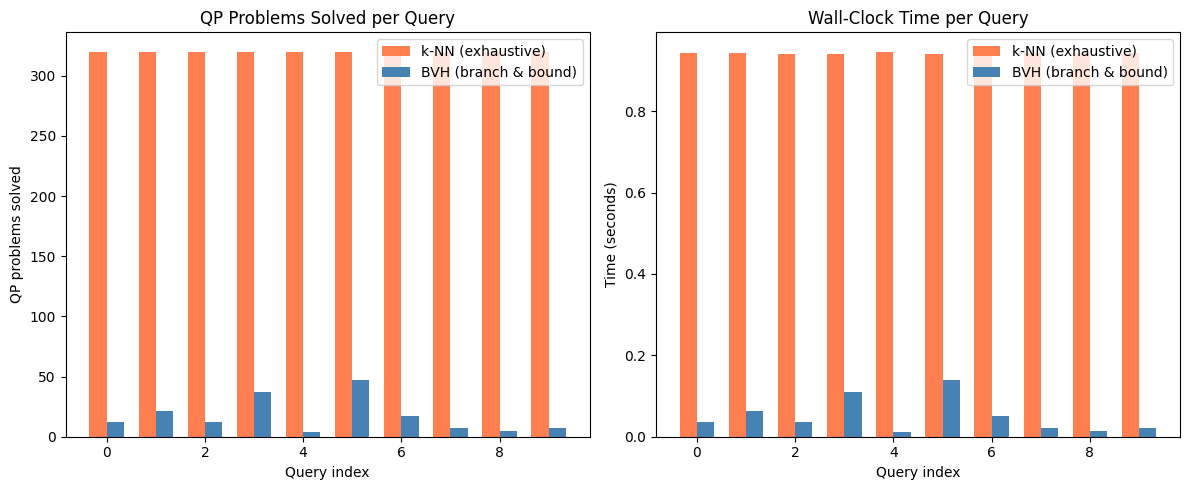

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pos = np.arange(n_test)
width = 0.35

ax = axes[0]
ax.bar(x_pos - width/2, knn_qps, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_qps, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('QP problems solved')
ax.set_title('QP Problems Solved per Query')
ax.legend()

ax = axes[1]
ax.bar(x_pos - width/2, knn_times, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_times, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('Time (seconds)')
ax.set_title('Wall-Clock Time per Query')
ax.legend()

plt.tight_layout()
plt.show()

## 9 – Counterfactual Quality Metrics

In [17]:
from sklearn.neighbors import LocalOutlierFactor

source_digits = [0, 1, 2]
n_queries_per = 10

rows = []
for sc in source_digits:
    queries = atlas.bounds[sc]['X'][:n_queries_per]

    for tc in range(n_classes):
        if tc == sc:
            continue

        target_data = atlas.bounds[tc]['X']
        n_neighbors = min(10, len(target_data) - 1)
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
        lof.fit(target_data)

        for i, x_q in enumerate(queries):
            result = atlas.find_counterfactual(x_q, tc, method='bvh')
            if not result.success:
                continue

            x_cf = result.x_cf
            x_diff = x_cf - x_q

            rows.append({
                'source': sc,
                'target': tc,
                'query_idx': i,
                'l2_distance': np.linalg.norm(x_diff),
                'linf_distance': np.max(np.abs(x_diff)),
                'lof_score': -lof.score_samples(x_cf.reshape(1, -1))[0],
                'n_qp_solved': result.n_qp_solved,
            })

metrics_df = pd.DataFrame(rows)
print(f'Generated {len(metrics_df)} counterfactuals\n')
metrics_df.head(10)

Generated 120 counterfactuals



,source,target,query_idx,l2_distance,linf_distance,lof_score,n_qp_solved
0,0,1,0,0.653833,0.560591,2.217037,62
1,0,1,1,0.455463,0.439378,2.163783,23
2,0,1,2,0.656428,0.562116,0.988385,78
3,0,1,3,0.259824,0.231175,3.216949,76
4,0,1,4,0.690120,0.685815,0.988385,79
5,0,1,5,0.130078,0.117581,3.138650,69
6,0,1,6,0.453247,0.446772,2.163783,37
7,0,1,7,0.807750,0.684318,1.183278,100
8,0,1,8,0.807694,0.760209,1.183278,91
9,0,1,9,0.381141,0.381122,2.163783,1


INFO     18:25:37     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:37     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:37     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:37     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     18:25:37     [category.py:224] Using categorical units to plot a list o

/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


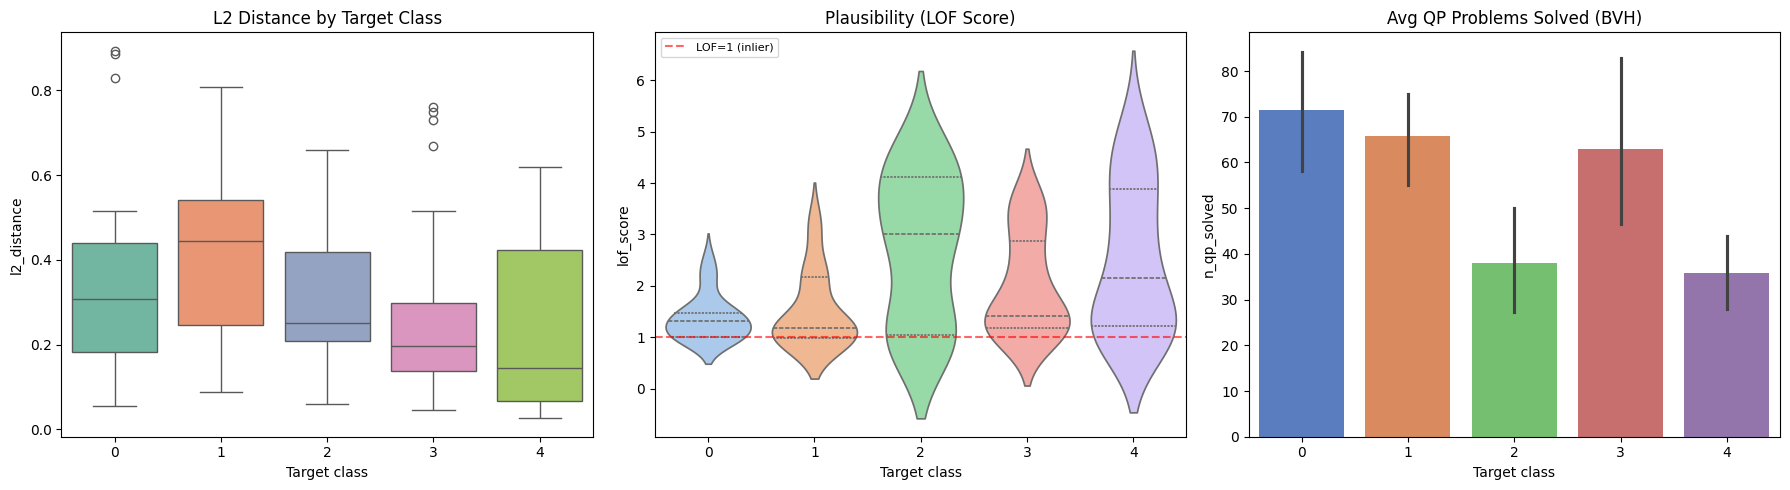

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# L2 distance by target
sns.boxplot(ax=axes[0], x='target', y='l2_distance', data=metrics_df,
            hue='target', palette='Set2', legend=False)
axes[0].set_title('L2 Distance by Target Class')
axes[0].set_xlabel('Target class')

# LOF plausibility
sns.violinplot(ax=axes[1], x='target', y='lof_score', data=metrics_df,
               hue='target', palette='pastel', legend=False, inner='quart')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='LOF=1 (inlier)')
axes[1].set_title('Plausibility (LOF Score)')
axes[1].set_xlabel('Target class')
axes[1].legend(fontsize=8)

# QPs solved
sns.barplot(ax=axes[2], x='target', y='n_qp_solved', data=metrics_df,
            hue='target', palette='muted', legend=False, estimator='mean')
axes[2].set_title('Avg QP Problems Solved (BVH)')
axes[2].set_xlabel('Target class')

plt.tight_layout()
plt.show()

## Summary

On the 2D spiral dataset, we can **directly visualize** and validate the preimage approximation quality:

- **Polytope shapes** are visible as filled polygons overlaid on the decision boundary
- **Chebyshev radius**, **volume ratio**, and **exact polygon area** quantify how much of the perturbation ball is certified
- **Value-add metrics** (CF/NN ratio, displacement) show whether the polytopes provide counterfactuals closer than nearest-neighbor
- These same metrics generalize to high-D (notebook 3.1), where visualization is impossible but the quantitative diagnostics still apply